In [1]:
import main
import rasterio

In [2]:
filename = "./assets/rst/clippedDem_12N.tif"
rasterObj = rasterio.open(filename)

In [3]:
from rasterio.plot import show

In [4]:
elevationArray = rasterObj.read(1)
main.describe_elevation(elevationArray)

Elevation Array: 
 [[1475 1470 1467 ... 1809 1809 1808]
 [1469 1464 1460 ... 1816 1816 1816]
 [1461 1458 1453 ... 1815 1819 1820]
 ...
 [1618 1616 1616 ... 1752 1753 1754]
 [1621 1617 1617 ... 1743 1745 1749]
 [1621 1617 1617 ... 1739 1740 1743]]
Shape: 
 (535, 544)
Data Type: 
 int16
No. of NoData Values: 
 0
Min Value: 
 1339
Max Value: 
 2056
Mean Value: 
 1689.870419873557
Std Value: 
 113.87570895303827


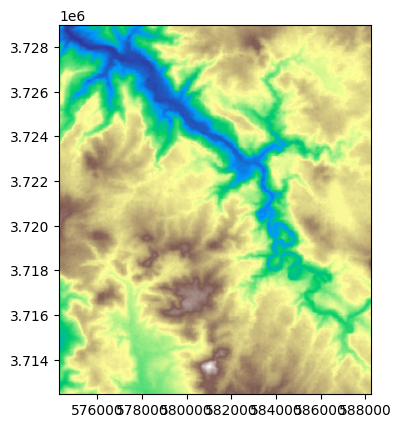

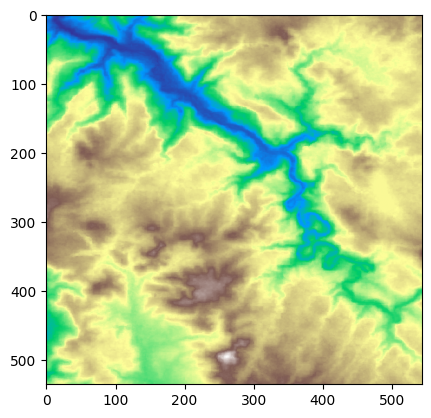

<Axes: >

In [5]:
show(rasterObj, cmap="terrain")
show(elevationArray, cmap="terrain")

In [6]:
ncols = rasterObj.width
nrows = rasterObj.height
print("ncols: ", ncols)
print("nrows: ", nrows)
res = rasterObj.res
print("resolution: ", res)
print("xllcorner: ", rasterObj.bounds.left)
print("yllcorner: ", rasterObj.bounds.bottom)
print("xurcorner: ", rasterObj.bounds.right)
print("yurcorner: ", rasterObj.bounds.top)
print("crs: ", rasterObj.crs)
print("epsg: ", rasterObj.crs.to_epsg())
print("bounds: ", rasterObj.bounds)
print("transform: ", rasterObj.transform)
print("tags: ", rasterObj.tags())
print("tags(ns): ", rasterObj.tags(ns=""))
print("tags(ns=foo): ", rasterObj.tags(ns="foo"))
print("tags(ns=bar): ", rasterObj.tags(ns="bar"))
dxy = (rasterObj.transform.a,-rasterObj.transform.e)  # side length of a raster model cell, or resolution [m], initially 50
print("dxy: ", dxy)

ncols:  544
nrows:  535
resolution:  (25.65010730167443, 30.922000999722275)
xllcorner:  574306.4323383475
yllcorner:  3712453.2796844486
xurcorner:  588260.0907104585
yurcorner:  3728996.5502193
crs:  EPSG:26712
epsg:  26712
bounds:  BoundingBox(left=574306.4323383475, bottom=3712453.2796844486, right=588260.0907104585, top=3728996.5502193)
transform:  | 25.65, 0.00, 574306.43|
| 0.00,-30.92, 3728996.55|
| 0.00, 0.00, 1.00|
tags:  {'AREA_OR_POINT': 'Area'}
tags(ns):  {'AREA_OR_POINT': 'Area'}
tags(ns=foo):  {}
tags(ns=bar):  {}
dxy:  (25.65010730167443, 30.922000999722275)


535 544 (25.65010730167443, 30.922000999722275)


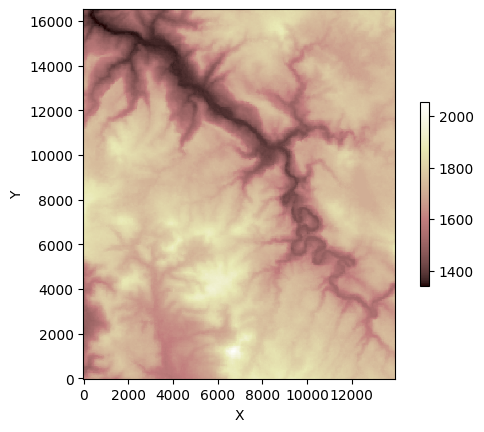

In [7]:
mg = main.createGridFromRaster(ncols, nrows, res,elevationArray)

In [8]:
from landlab.components.overland_flow import OverlandFlow
import numpy as np

#set and apply and initial height

initialHeight = 3
depthArray = np.ones(elevationArray.shape)*initialHeight
mg.at_node["surface_water__depth"] = depthArray
#define the flood objeds
of = OverlandFlow(mg, steep_slopes=True)

In [9]:
#list to store times
dtList = []
#Run once and store elapsed time
of.run_one_step()
dtList.append(of.dt)
print(of.dt)

3.3102861522485703


In [10]:
# explore the output data and location

# model outputs
print(of.output_var_names)

# where this nodes are locates
print(of.var_loc("surface_water__depth"))

# show the water depth array
print(mg.at_node["surface_water__depth"])
('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')



('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')
node
[3.00001 3.00001 3.00001 ... 3.00001 3.00001 3.00001]


('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')

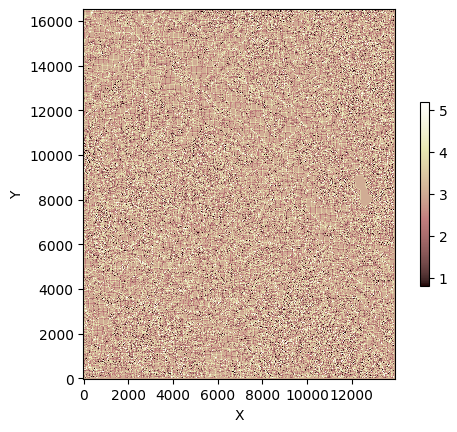

In [11]:
from landlab import RasterModelGrid, imshow_grid
# plot the resulting water depth for the first run
imshow_grid(mg, "surface_water__depth", shrink=0.5)


In [12]:
# run the model for 100 time steps
for i in range(100):
    of.run_one_step()
    dtList.append(of.dt)
    print("Time step: %.2f seconds. Elapsed time %.2f seconds"%(of.dt,sum(dtList)))

Time step: 2.52 seconds. Elapsed time 5.83 seconds
Time step: 1.98 seconds. Elapsed time 7.81 seconds
Time step: 1.65 seconds. Elapsed time 9.46 seconds
Time step: 1.49 seconds. Elapsed time 10.95 seconds
Time step: 1.45 seconds. Elapsed time 12.40 seconds
Time step: 1.41 seconds. Elapsed time 13.81 seconds
Time step: 1.38 seconds. Elapsed time 15.19 seconds
Time step: 1.33 seconds. Elapsed time 16.52 seconds
Time step: 1.29 seconds. Elapsed time 17.81 seconds
Time step: 1.25 seconds. Elapsed time 19.06 seconds
Time step: 1.22 seconds. Elapsed time 20.28 seconds
Time step: 1.19 seconds. Elapsed time 21.47 seconds
Time step: 1.16 seconds. Elapsed time 22.63 seconds
Time step: 1.14 seconds. Elapsed time 23.77 seconds
Time step: 1.13 seconds. Elapsed time 24.90 seconds
Time step: 1.12 seconds. Elapsed time 26.02 seconds
Time step: 1.11 seconds. Elapsed time 27.13 seconds
Time step: 1.10 seconds. Elapsed time 28.24 seconds
Time step: 1.09 seconds. Elapsed time 29.33 seconds
Time step: 1.08

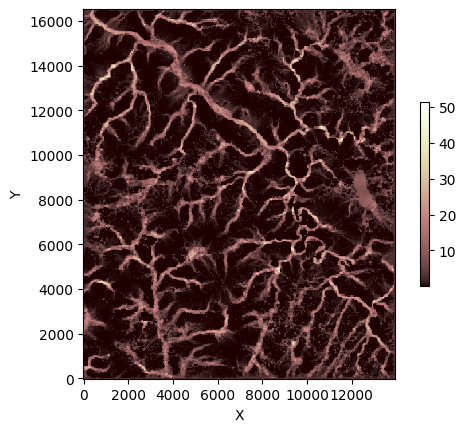

In [13]:
# plot the resulting water depth for the 101th run
imshow_grid(mg, "surface_water__depth", shrink=0.5)

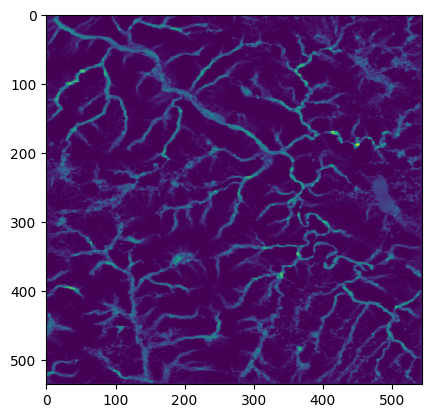

In [14]:
from matplotlib import pyplot as plt

#convert the resulting data to a numpy array
zArray = mg.at_node["surface_water__depth"].reshape((nrows,ncols))[::-1,:]
#plot the array
plt.imshow(zArray)

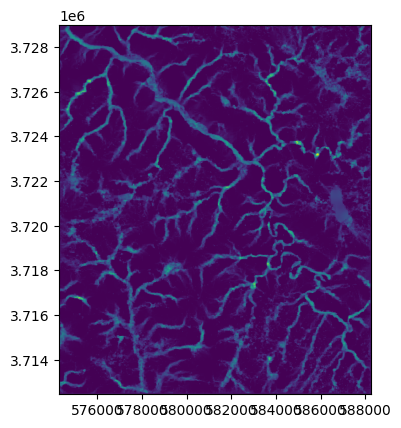

<Axes: >

In [18]:
# Write the array to a new GeoTIFF file
with rasterio.open(
        './Out/floodSurfaceDepth.tif',
        'w',
        driver='GTiff',
        height=rasterObj.height,
        width=rasterObj.width,
        count=1,  # number of bands
        dtype=zArray.dtype,
        crs=rasterObj.crs,
        transform=rasterObj.transform
) as dst:
    dst.write(zArray, 1)  # write the data to the first band
# Show the resulting raster
floodObj = rasterio.open('./Out/floodSurfaceDepth.tif')
show(floodObj)

In [19]:
import rasterio
from landlab.io import read_esri_ascii
from landlab import RasterModelGrid
import numpy as np

with rasterio.open('./Out/floodSurfaceDepth.tif') as src:
    dem_data = src.read(1, masked=True)
    transform = src.transform
    dx = transform[0]

# Crear el grid de Landlab
nrows, ncols = dem_data.shape
mg = RasterModelGrid((nrows, ncols), dx)
z = mg.add_field("topographic__elevation", dem_data.filled(np.nan), at="node")


In [20]:
from landlab.components import DepressionFinderAndRouter

# Rellenar depresiones
z[np.isnan(z)] = z[~np.isnan(z)].min()  # Evitar nodos NaN para procesamiento
depr_finder = DepressionFinderAndRouter(mg)
depr_finder.map_depressions()


In [21]:
from landlab.components import FlowAccumulator

fa = FlowAccumulator(mg)
fa.run_one_step()


In [22]:
from landlab.components import BasinMapper

# Necesitas definir puntos de salida (outlet) para cada cuenca
# Por ejemplo, nodo más bajo o más a la derecha:
outlet_nodes = [mg.node_at_cell_center[-1]]  # ejemplo sencillo

bm = BasinMapper(mg, outlets=outlet_nodes)
bm.map_basins()

# Resultado: campo 'basin__id' con ID por cada cuenca
basins = mg.at_node['basin__id']


ImportError: cannot import name 'BasinMapper' from 'landlab.components' (/home/juanguerrero09/dev/dampy/.venv/lib/python3.12/site-packages/landlab/components/__init__.py)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
imshow = mg.plot_var('basin__id', cmap='tab20')
plt.colorbar(imshow, label='ID de Cuenca')
plt.title("Delimitación de Cuencas con Landlab")
plt.show()
